Nous allons maintenant appliqué les principaux modèles sur nos données avec validation croisée mesurée par différentes métriques (RMSE, R², MAE)

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

PROCESSED_DIR = os.path.join("..", "data", "processed")
TARGETS = ["Yield_strength", "UTS", "Elongation", "Reduction_area", "Charpy_energy"]
UNITS = {"Yield_strength": "MPa", "UTS": "MPa", "Elongation": "%", "Reduction_area": "%", "Charpy_energy": "J"}
CAT_COLS = ["AC_DC", "Polarity", "Weld_type"]
ALLOY_COLS = ["Cu_wt", "Mo_wt", "Ni_wt", "Cr_wt", "V_wt"]
DROP_COLS = ["W_wt", "Co_wt"]          # ~90 % missing, identical missing pattern (notebook 2)
ALLOY_INDICATOR = True                 # add a "was missing" flag for alloying elements
RANDOM_STATE = 42

Chargement des variables

In [49]:
def add_features(X):
    """Deterministic feature engineering (no statistic learned from the data)."""
    X = X.copy()
    # PWHT_temp = 0 means "no post-weld heat treatment", not a real temperature
    X["PWHT_done"] = (X["PWHT_temp"] > 0).astype(float)
    return X


def load_target(target):
    """Load the raw train / test split of one target (exported by notebook 1)."""
    path = os.path.join(PROCESSED_DIR, f"welddb_split_{target.lower()}.csv")
    data = pd.read_csv(path)
    out = {}
    for split in ["train", "test"]:
        part = data[data["split"] == split].drop(columns="split").reset_index(drop=True)
        X = add_features(part.drop(columns=[target] + DROP_COLS, errors="ignore"))
        out[split] = (X, part[target])
    return out


datasets = {t: load_target(t) for t in TARGETS}
for t, d in datasets.items():
    print(f"{t:>15}: train {d['train'][0].shape} | test {d['test'][0].shape}")

 Yield_strength: train (623, 29) | test (156, 29)
            UTS: train (589, 29) | test (148, 29)
     Elongation: train (559, 29) | test (140, 29)
 Reduction_area: train (563, 29) | test (141, 29)
  Charpy_energy: train (703, 30) | test (176, 30)


Prétraitement (Pipeline)

In [50]:
def make_preprocessor(columns):
    """Unfitted preprocessing: everything is learned on the training fold only."""
    ppm_cols = [c for c in columns if c.endswith("_ppm")]
    alloy_cols = [c for c in ALLOY_COLS if c in columns]
    cat_cols = [c for c in CAT_COLS if c in columns]
    other_cols = [c for c in columns if c not in ppm_cols + alloy_cols + cat_cols]

    ppm_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value=0.0, keep_empty_features=True)),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
    ])
    alloy_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value=0.0,
                                 add_indicator=ALLOY_INDICATOR, keep_empty_features=True)),
        ("scale", StandardScaler()),
    ])
    other_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("scale", StandardScaler()),
    ])
    cat_pipe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    return ColumnTransformer([
        ("ppm", ppm_pipe, ppm_cols),
        ("alloy", alloy_pipe, alloy_cols),
        ("other", other_pipe, other_cols),
        ("cat", cat_pipe, cat_cols),
    ])


def make_pipeline(model, columns):
    return Pipeline([("prep", make_preprocessor(columns)), ("model", clone(model))])

Modèle : on rescence nos différents modèles

In [51]:
MODELS = {
    "Baseline (median)": DummyRegressor(strategy="median"),
    "Ridge": Ridge(alpha=10.0),
    "kNN": KNeighborsRegressor(n_neighbors=7, weights="distance"),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

Validation croisée (5 folds, sur le train)

In [52]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"r2": "r2", "rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

rows = []
for target in TARGETS:
    X_tr, y_tr = datasets[target]["train"]
    for name, model in MODELS.items():
        pipe = make_pipeline(model, list(X_tr.columns))
        res = cross_validate(pipe, X_tr, y_tr, cv=cv, scoring=SCORING)
        rows.append({
            "target": target, "model": name,
            "r2": res["test_r2"].mean(), "r2_std": res["test_r2"].std(),
            "rmse": -res["test_rmse"].mean(), "rmse_std": res["test_rmse"].std(),
            "mae": -res["test_mae"].mean(), "mae_std": res["test_mae"].std(),
        })
    print(f"{target}: done")

cv_results = pd.DataFrame(rows)
cv_results.round(3)

Yield_strength: done
UTS: done
Elongation: done
Reduction_area: done
Charpy_energy: done


,target,model,r2,r2_std,rmse,rmse_std,mae,mae_std
0,Yield_strength,Baseline (median),-0.033,0.041,92.681,8.588,69.896,4.646
1,Yield_strength,Ridge,0.468,0.061,66.400,6.846,48.294,4.234
2,Yield_strength,kNN,0.594,0.065,57.854,7.036,40.487,2.835
3,Yield_strength,Random Forest,0.765,0.053,43.905,6.306,30.961,1.582
4,Yield_strength,Gradient Boosting,0.783,0.051,42.291,6.620,30.036,2.637
5,UTS,Baseline (median),-0.070,0.064,88.097,2.689,67.526,1.318
6,UTS,Ridge,0.632,0.099,51.158,5.813,36.839,3.270
7,UTS,kNN,0.734,0.070,43.657,5.956,31.443,3.877
8,UTS,Random Forest,0.813,0.088,35.986,7.208,25.405,2.957
9,UTS,Gradient Boosting,0.844,0.082,32.669,7.381,23.574,3.317


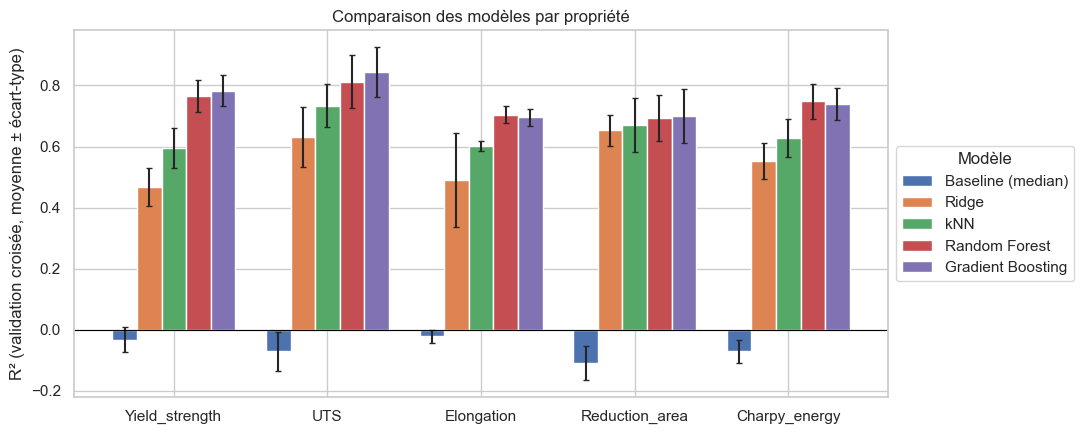

In [53]:
r2_table = cv_results.pivot(index="model", columns="target", values="r2")[TARGETS]
r2_std = cv_results.pivot(index="model", columns="target", values="r2_std")[TARGETS]
r2_table = r2_table.loc[list(MODELS)]
r2_std = r2_std.loc[list(MODELS)]

fig, ax = plt.subplots(figsize=(11, 4.5))
r2_table.T.plot.bar(yerr=r2_std.T, ax=ax, capsize=2, width=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("R² (validation croisée, moyenne ± écart-type)")
ax.set_xlabel("")
ax.set_title("Comparaison des modèles par propriété")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Modèle")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Evalutation des modèles, on récupère les meilleurs pour chaque target

In [54]:
def evaluate(model, columns, X_tr, y_tr, X_te, y_te):
    pipe = make_pipeline(model, columns).fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return pipe, pred, {
        "r2": r2_score(y_te, pred),
        "rmse": np.sqrt(mean_squared_error(y_te, pred)),
        "mae": mean_absolute_error(y_te, pred),
    }


best_idx = cv_results.groupby("target")["rmse"].idxmin()
best_models = cv_results.loc[best_idx].set_index("target")["model"]

test_rows, preds = [], {}
for target in TARGETS:
    X_tr, y_tr = datasets[target]["train"]
    X_te, y_te = datasets[target]["test"]
    cols = list(X_tr.columns)

    best_name = best_models[target]
    _, pred, m_best = evaluate(MODELS[best_name], cols, X_tr, y_tr, X_te, y_te)
    _, _, m_base = evaluate(MODELS["Baseline (median)"], cols, X_tr, y_tr, X_te, y_te)
    preds[target] = (y_te, pred, best_name)

    test_rows.append({"target": target, "unit": UNITS[target], "best model": best_name,
                      "R² test": m_best["r2"], "RMSE test": m_best["rmse"], "MAE test": m_best["mae"],
                      "R² baseline": m_base["r2"], "RMSE baseline": m_base["rmse"]})

test_results = pd.DataFrame(test_rows).set_index("target")
test_results.round(3)

,unit,best model,R² test,RMSE test,MAE test,R² baseline,RMSE baseline
target,,,,,,,
Yield_strength,MPa,Gradient Boosting,0.828,40.039,28.681,-0.046,98.749
UTS,MPa,Gradient Boosting,0.769,47.742,28.290,-0.059,102.233
Elongation,%,Random Forest,0.790,2.255,1.722,-0.026,4.989
Reduction_area,%,Gradient Boosting,0.732,4.285,2.398,-0.006,8.306
Charpy_energy,J,Random Forest,0.824,22.129,16.254,-0.049,54.024


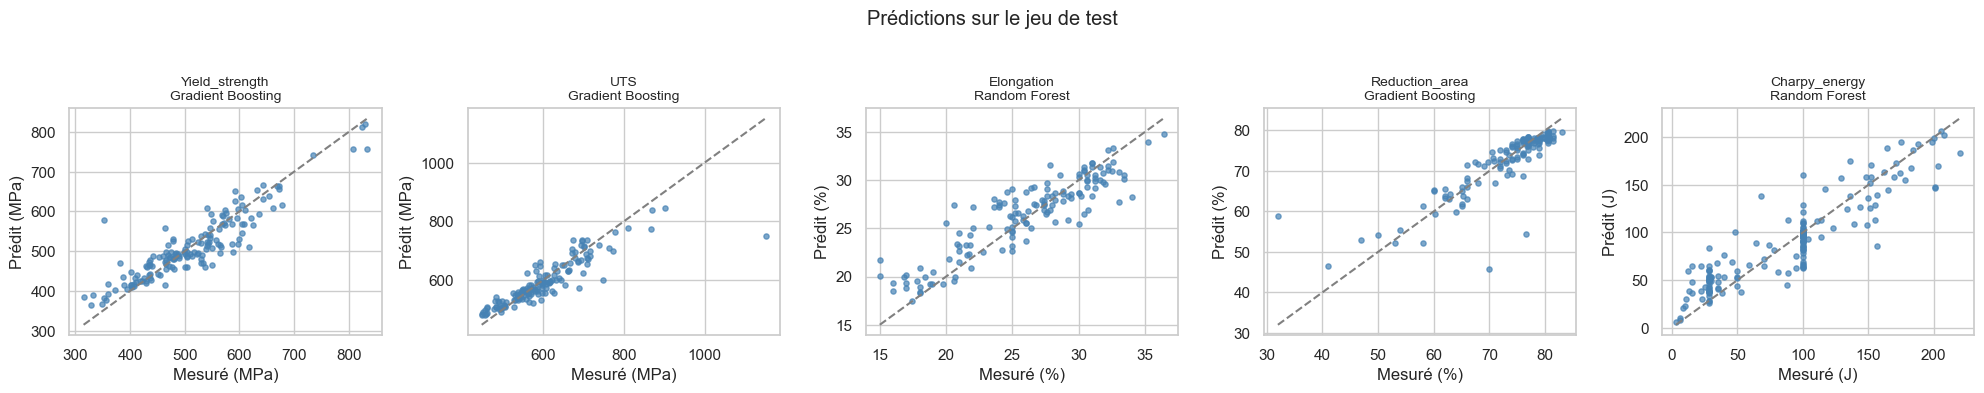

In [55]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(4 * len(TARGETS), 3.8))
for ax, target in zip(axes, TARGETS):
    y_te, pred, name = preds[target]
    ax.scatter(y_te, pred, s=14, alpha=0.7, color="steelblue")
    lims = [min(y_te.min(), pred.min()), max(y_te.max(), pred.max())]
    ax.plot(lims, lims, "--", color="gray")
    ax.set_title(f"{target}\n{name}", fontsize=10)
    ax.set_xlabel(f"Mesuré ({UNITS[target]})")
    ax.set_ylabel(f"Prédit ({UNITS[target]})")
plt.suptitle("Prédictions sur le jeu de test", y=1.03)
plt.tight_layout()
plt.show()

In [56]:
from sklearn.model_selection import GroupKFold

X_tr, y_tr = datasets["Yield_strength"]["train"]
chem_cols = [c for c in X_tr.columns if c.endswith(("_wt", "_ppm"))]
groups = X_tr.groupby(chem_cols, dropna=False).ngroup()   

pipe = make_pipeline(MODELS["Random Forest"], list(X_tr.columns))
for name, splitter in {"KFold": cv, "GroupKFold": GroupKFold(5)}.items():
    r2 = cross_validate(pipe, X_tr, y_tr, cv=splitter, groups=groups, scoring="r2")["test_score"]
    print(f"{name:>10}: R² = {r2.mean():.2f} ± {r2.std():.2f}")

c:\Users\xavie\miniconda3\Lib\site-packages\sklearn\model_selection\_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(


     KFold: R² = 0.77 ± 0.05
GroupKFold: R² = 0.71 ± 0.04
